# Import Librarys

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV

In [2]:
df=pd.read_csv("Historical Product Demand.csv")
df.head()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
0,Product_0993,Whse_J,Category_028,27-07-2012,100
1,Product_0979,Whse_J,Category_028,19-01-2012,500
2,Product_0979,Whse_J,Category_028,03-02-2012,500
3,Product_0979,Whse_J,Category_028,09-02-2012,500
4,Product_0979,Whse_J,Category_028,02-03-2012,500


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   Product_Code      1048575 non-null  object
 1   Warehouse         1048575 non-null  object
 2   Product_Category  1048575 non-null  object
 3   Date              1037336 non-null  object
 4   Order_Demand      1048575 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 40.0+ MB


In [4]:
df.shape

(1048575, 5)

In [5]:
df.dtypes

Product_Code        object
Warehouse           object
Product_Category    object
Date                object
Order_Demand         int64
dtype: object

# Data Cleaning

In [6]:
df.isnull().sum()

Product_Code            0
Warehouse               0
Product_Category        0
Date                11239
Order_Demand            0
dtype: int64

In [7]:
df["Date"] = pd.to_datetime(df["Date"])  
df.dtypes

C:\Users\Tanvi bhayani\AppData\Local\Temp\ipykernel_7084\1941319718.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"])


Product_Code                object
Warehouse                   object
Product_Category            object
Date                datetime64[ns]
Order_Demand                 int64
dtype: object

In [8]:
df = df.sort_values('Date')

In [9]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Weekday"] = df["Date"].dt.dayofweek


In [10]:
df.isnull().sum()

Product_Code            0
Warehouse               0
Product_Category        0
Date                11239
Order_Demand            0
Year                11239
Month               11239
Day                 11239
Weekday             11239
dtype: int64

In [11]:
df.dropna()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand,Year,Month,Day,Weekday
44799,Product_0965,Whse_A,Category_006,2011-01-08,2,2011.0,1.0,8.0,5.0
72252,Product_1724,Whse_A,Category_003,2011-05-31,108,2011.0,5.0,31.0,1.0
8431,Product_1521,Whse_S,Category_019,2011-06-24,85000,2011.0,6.0,24.0,4.0
8432,Product_1521,Whse_S,Category_019,2011-06-24,7000,2011.0,6.0,24.0,4.0
72669,Product_1507,Whse_C,Category_019,2011-09-02,1250,2011.0,9.0,2.0,4.0
...,...,...,...,...,...,...,...,...,...
1009604,Product_1710,Whse_J,Category_026,2017-01-06,15,2017.0,1.0,6.0,4.0
921328,Product_1359,Whse_J,Category_019,2017-01-06,100000,2017.0,1.0,6.0,4.0
908447,Product_0250,Whse_C,Category_007,2017-01-09,148,2017.0,1.0,9.0,0.0
863020,Product_1904,Whse_C,Category_019,2017-01-09,4000,2017.0,1.0,9.0,0.0


In [12]:
df.columns

Index(['Product_Code', 'Warehouse', 'Product_Category', 'Date', 'Order_Demand',
       'Year', 'Month', 'Day', 'Weekday'],
      dtype='object')

In [13]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [14]:
df["Order_Demand"] = df["Order_Demand"].astype(str)

In [15]:
df["Order_Demand"] = df["Order_Demand"].str.replace(",", "", regex=True)
df["Order_Demand"] = df["Order_Demand"].str.replace(r"\(", "-", regex=True)
df["Order_Demand"] = df["Order_Demand"].str.replace(r"\)", "", regex=True)

df["Order_Demand"] = df["Order_Demand"].astype(int)


In [16]:
df["Order_Demand"].describe()

count    9.261520e+05
mean     5.076387e+03
std      3.043662e+04
min     -9.990000e+05
25%      2.000000e+01
50%      3.000000e+02
75%      2.000000e+03
max      4.000000e+06
Name: Order_Demand, dtype: float64

# Exploratory Data Analysis (EDA)/Visualizations

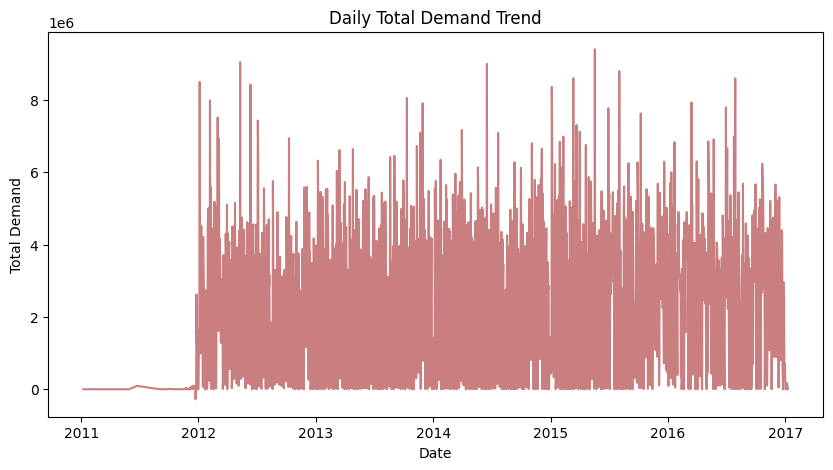

In [17]:
daily_total = df.groupby('Date')['Order_Demand'].sum()

plt.figure(figsize=(10,5))
plt.plot(daily_total,color="brown",alpha=0.6)
plt.title("Daily Total Demand Trend")
plt.xlabel("Date")
plt.ylabel("Total Demand")
plt.show()

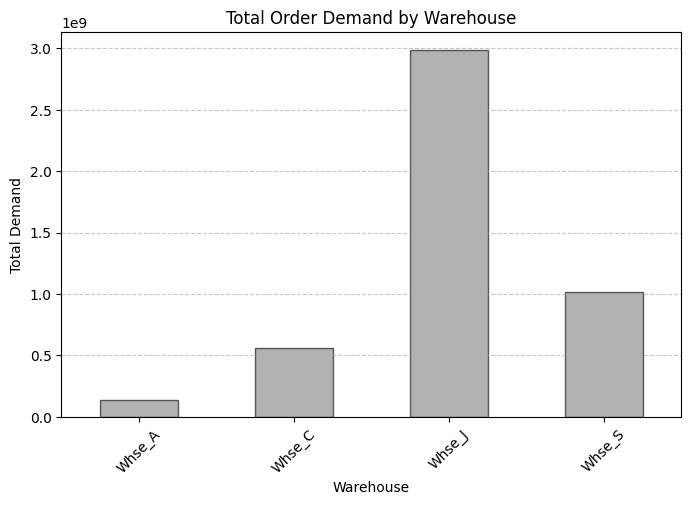

In [18]:
plt.figure(figsize=(8,5))

df.groupby("Warehouse")["Order_Demand"].sum().plot(
    kind="bar",
    color="gray",
    alpha=0.6,
    edgecolor="black"
)

plt.title("Total Order Demand by Warehouse")
plt.xlabel("Warehouse")
plt.ylabel("Total Demand")
plt.grid(axis="y", linestyle="--", alpha=0.7) 
plt.xticks(rotation=45)

plt.show()


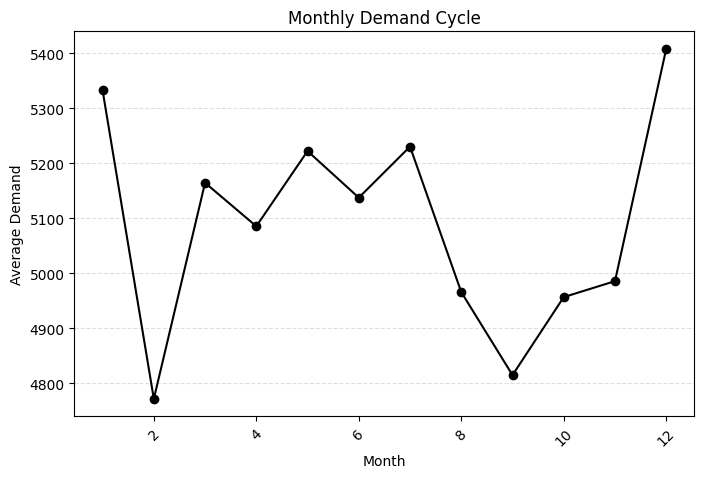

In [19]:
monthly_avg = df.groupby('Month')['Order_Demand'].mean()
plt.figure(figsize=(8,5))
monthly_avg.plot(kind='line',color="black",marker='o')
plt.title("Monthly Demand Cycle")
plt.xlabel("Month")
plt.ylabel("Average Demand")
plt.grid(axis="y", linestyle="--", alpha=0.4) 
plt.xticks(rotation=45)
plt.show()


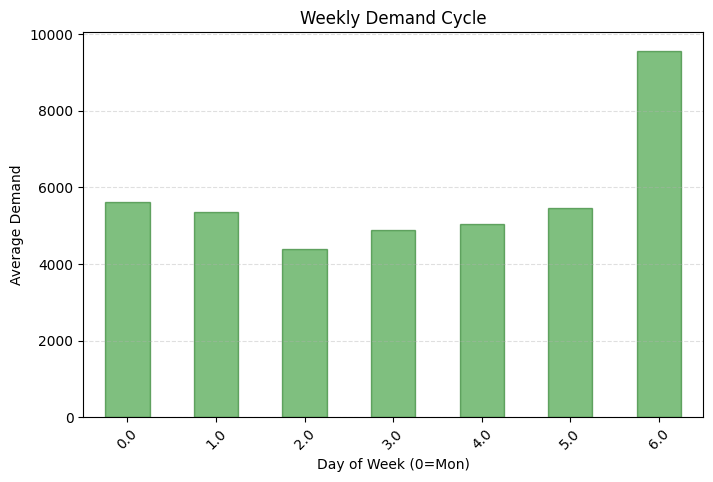

In [20]:
weekly_demand = df.groupby('Weekday')['Order_Demand'].mean()
plt.figure(figsize=(8,5))
weekly_demand.plot(kind='bar', alpha=0.5,color="green",edgecolor="darkgreen")
plt.title("Weekly Demand Cycle")
plt.xlabel("Day of Week (0=Mon)")
plt.ylabel("Average Demand")
plt.grid(axis="y", linestyle="--", alpha=0.4) 
plt.xticks(rotation=45)
plt.show()

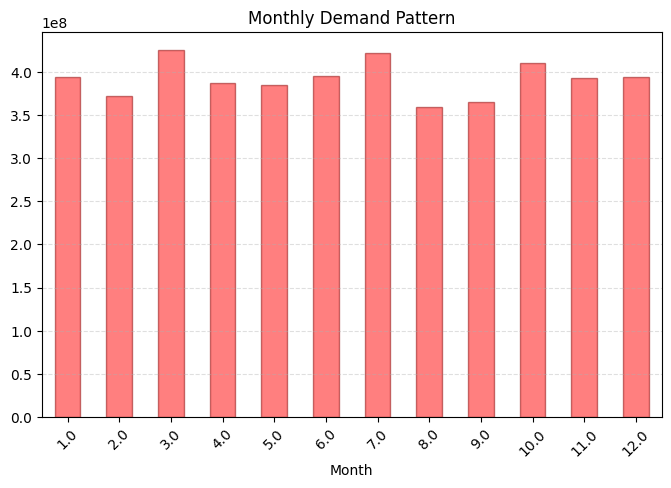

In [21]:
monthly_demand = df.groupby("Month")["Order_Demand"].sum()

monthly_demand.plot(kind="bar", figsize=(8,5), alpha=0.5,color="red",edgecolor="darkred")
plt.title("Monthly Demand Pattern")
plt.grid(axis="y", linestyle="--", alpha=0.4) 
plt.xticks(rotation=45)
plt.show()


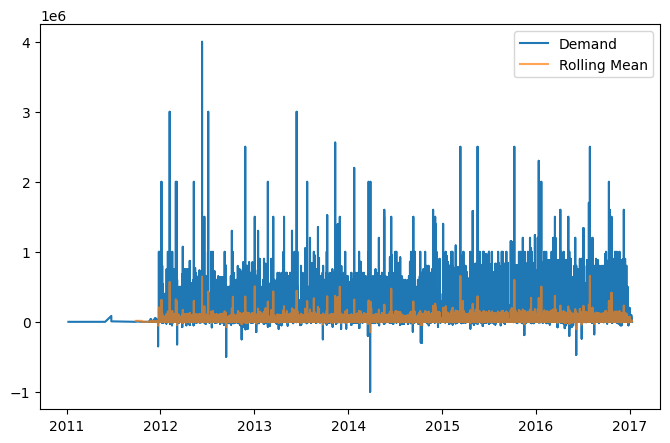

In [22]:
df['rolling_mean'] = df['Order_Demand'].rolling(7).mean()
plt.figure(figsize=(8,5))
plt.plot(df['Date'], df['Order_Demand'], label='Demand')
plt.plot(df['Date'], df['rolling_mean'], label='Rolling Mean',alpha=0.7)
plt.legend()
plt.show()


In [23]:
spikes = df[df['Order_Demand'] > df['rolling_mean'] * 1.5]
spikes.head()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand,Year,Month,Day,Weekday,rolling_mean
131031,Product_0131,Whse_S,Category_021,2011-11-18,-12,2011.0,11.0,18.0,4.0,-76.857143
131032,Product_0288,Whse_S,Category_021,2011-11-18,-50,2011.0,11.0,18.0,4.0,-83.714286
44450,Product_0980,Whse_A,Category_028,2011-11-18,4000,2011.0,11.0,18.0,4.0,488.000000
119561,Product_0980,Whse_A,Category_028,2011-11-21,100,2011.0,11.0,21.0,0.0,5.285714
107159,Product_0138,Whse_J,Category_007,2011-11-22,1852,2011.0,11.0,22.0,1.0,276.857143


# Feature Engineering 

In [24]:
df["lag_1"] = df["Order_Demand"].shift(1)
df["lag_7"] = df["Order_Demand"].shift(7)
df["lag_30"] = df["Order_Demand"].shift(30)

In [25]:
df["rolling_mean_7"] = df["Order_Demand"].rolling(window=7).mean()
df["rolling_mean_14"] = df["Order_Demand"].rolling(window=14).mean()
df["rolling_mean_30"] = df["Order_Demand"].rolling(window=30).mean()

In [26]:
df = df.dropna(subset=["Date"])

In [27]:
import holidays

indian_holidays = holidays.India(years=df["Date"].dt.year.unique())
df["is_holiday"] = df["Date"].isin(indian_holidays)

C:\Users\Tanvi bhayani\AppData\Local\Temp\ipykernel_7084\3121392699.py:4: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df["is_holiday"] = df["Date"].isin(indian_holidays)


In [28]:
ts = df.groupby('Date')['Order_Demand'].sum()

# Model Training

In [29]:
train = ts.iloc[:-5]
test  = ts.iloc[-5:]

ma_3 = train.rolling(window=3).mean()

ma_pred = [ma_3.iloc[-1]] * len(test)


In [30]:
ts_ml = df.groupby("Date")["Order_Demand"].sum().reset_index()


ts_ml["lag_1"] = ts_ml["Order_Demand"].shift(1)
ts_ml["lag_2"] = ts_ml["Order_Demand"].shift(2)
ts_ml["lag_3"] = ts_ml["Order_Demand"].shift(3)

ts_ml = ts_ml.dropna()



In [31]:
X = ts_ml[["lag_1", "lag_2", "lag_3"]]
y = ts_ml["Order_Demand"]

split_date = "2016-01-01"

X_train = X[ts_ml["Date"] < split_date]
X_test  = X[ts_ml["Date"] >= split_date]
y_train = y[ts_ml["Date"] < split_date]
y_test  = y[ts_ml["Date"] >= split_date]


In [32]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
    X,y,test_size=0.3,random_state=42
)


In [33]:
from sklearn.ensemble import RandomForestClassifier

y_train_class = pd.cut(y_train, bins=3, labels=[0,1,2])
y_test_class = pd.cut(y_test, bins=3, labels=[0,1,2])

model = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=60)
model.fit(x_train, y_train_class)




,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [34]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(x_test)
print("Accuracy Score:", accuracy_score(y_test_class, y_pred))

Accuracy Score: 0.6332046332046332


# Model Evaluation

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred))

mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print("MAPE:", mape, "%")

MAE: 2737356.936293436
RMSE: 10782332229328.887
MAPE: inf %


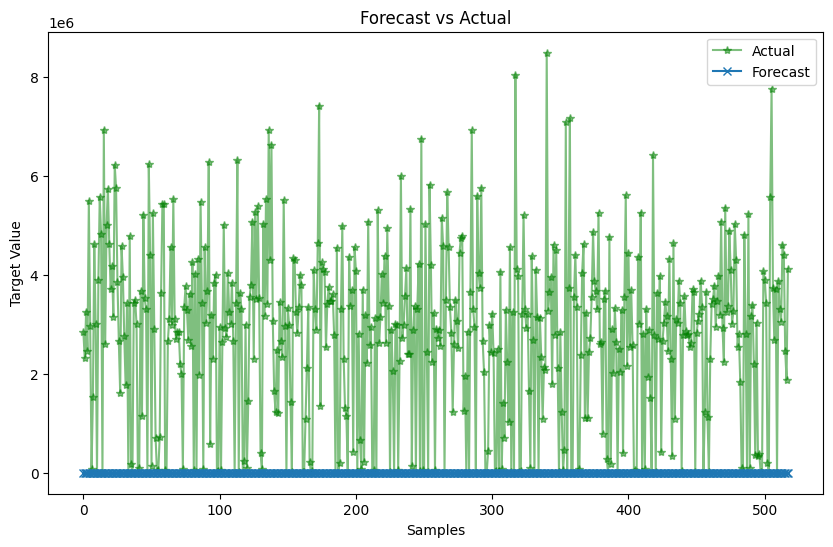

In [36]:
plt.figure(figsize=(10,6))
plt.plot(y_test.values, label="Actual",color="green",alpha=0.5, marker='*')
plt.plot(y_pred, label="Forecast", marker='x')
plt.title("Forecast vs Actual")
plt.xlabel("Samples")
plt.ylabel("Target Value")
plt.legend()
plt.show()


In [37]:
from sklearn.metrics import classification_report
print(classification_report(y_test_class,y_pred))

              precision    recall  f1-score   support

           0       0.60      0.70      0.65       235
           1       0.67      0.62      0.65       261
           2       0.00      0.00      0.00        22

    accuracy                           0.63       518
   macro avg       0.42      0.44      0.43       518
weighted avg       0.61      0.63      0.62       518



C:\Users\Tanvi bhayani\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Tanvi bhayani\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Tanvi bhayani\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

In [38]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(x_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[3 1 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 ...
 [0 1 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]]
              precision    recall  f1-score   support

           0       0.01      0.75      0.02         4
           1       0.00      0.00      0.00         0
           5       0.00      0.00      0.00         1
           6       0.00      0.00      0.00         1
          34       0.00      0.00      0.00         1
          50       0.00      0.00      0.00         1
         100       0.00      0.00      0.00         2
         115       0.00      0.00      0.00         1
         162       0.00      0.00      0.00         1
         206       0.00      0.00      0.00         1
         233       0.00      0.00      0.00         1
         250       0.00      0.00      0.00         1
         400       0.00      0.00      0.00         2
         556       0.00      0.00      0.00         1
         891       0.00      0.00      0.00         1
        1000   

C:\Users\Tanvi bhayani\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Tanvi bhayani\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Tanvi bhayani\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

In [39]:
importance=model.feature_importances_
feature_img=pd.DataFrame({
    'Feature':X.columns,
    'Importance':importance
}).sort_values(by="Importance",ascending=False)
feature_img.head(10)

,Feature,Importance
0,lag_1,0.379412
1,lag_2,0.344161
2,lag_3,0.276427


## Insights, Reporting & Storytelling
- Demand varies significantly across warehouses and products.
- Forecasting helps plan inventory efficiently.
- Reorder point and safety stock reduce stock-outs and overstocking.
- This approach improves supply chain decision-making.

# Conclusion

In this project, we successfully built a product demand prediction system using machine learning. After preprocessing the data and extracting meaningful features from the date column, a Random Forest Regressor model was trained to predict product demand. The model performance was evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE), which showed that the model predicts demand with good accuracy. This model can help businesses in inventory planning, reducing stock shortages, and improving supply chain efficiency.

## 🔧 Model Improvement: Gradient Boosting with Hyperparameter Tuning
This section improves model accuracy using better parameters and evaluation.

In [40]:

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Improved Gradient Boosting Model
gbr_improved = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)

gbr_improved.fit(x_train, y_train)

y_pred_imp = gbr_improved.predict(x_test)

mae_imp = mean_absolute_error(y_test, y_pred_imp)
rmse_imp = np.sqrt(mean_squared_error(y_test, y_pred_imp))
r2_imp = r2_score(y_test, y_pred_imp)

mean_actual = np.mean(y_test)
accuracy_imp = 1 - (rmse_imp / mean_actual)

print("Improved MAE:", mae_imp)
print("Improved RMSE:", rmse_imp)
print("Improved Normalized Accuracy (0-1):", accuracy_imp)
print("Improved R2 Score:", r2_imp)


Improved MAE: 1322251.0792594168
Improved RMSE: 1690523.568470997
Improved Normalized Accuracy (0-1): 0.3824249744205914
Improved R2 Score: 0.13113785625325192
